In [1]:
from itertools import combinations
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from collections import Counter
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from torch.utils.data import Dataset, DataLoader
import nltk
import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

In [2]:
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
if "Unnamed: 0" in df.columns:
    df.rename(columns={"Unnamed: 0": "number"}, inplace=True)

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

display(df.head())

Dataset Shape: (23486, 11)

Column Names:
['number', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


,number,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
def clean_text_data(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^\w\s\.\,\!\?\'\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Title"] = df["Title"].apply(clean_text_data)
df["Clean_Review"] = df["Review Text"].apply(clean_text_data)
df["Full_Review_Text"] = (df["Clean_Title"] + ". " + df["Clean_Review"]).str.strip().str.strip(".")
df["Full_Review_Text"] = df["Full_Review_Text"].apply(lambda x: x if len(x) > 0 else "No review provided")

df["Review_Word_Count"] = df["Full_Review_Text"].apply(lambda x: len(x.split()))
df["Review_Char_Count"] = df["Full_Review_Text"].apply(len)

display(df[["Title", "Review Text", "Full_Review_Text", "Review_Word_Count"]].head())

,Title,Review Text,Full_Review_Text,Review_Word_Count
0,NaN,Absolutely wonderful - silky and sexy and comf...,Absolutely wonderful - silky and sexy and com...,8
1,NaN,Love this dress! it's sooo pretty. i happene...,Love this dress! it's sooo pretty. i happened...,63
2,Some major design flaws,I had such high hopes for this dress and reall...,Some major design flaws. I had such high hopes...,102
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...","My favorite buy!. I love, love, love this jump...",25
4,Flattering shirt,This shirt is very flattering to all due to th...,Flattering shirt. This shirt is very flatterin...,38


In [4]:
nltk.download("vader_lexicon", quiet=True)
vader_analyzer = SentimentIntensityAnalyzer()

vader_results = [vader_analyzer.polarity_scores(t) for t in df["Full_Review_Text"]]

df["VADER_Compound"] = [s["compound"] for s in vader_results]
df["VADER_Pos"] = [s["pos"] for s in vader_results]
df["VADER_Neg"] = [s["neg"] for s in vader_results]
df["VADER_Neu"] = [s["neu"] for s in vader_results]

display(df[["Full_Review_Text", "Rating", "VADER_Compound", "VADER_Pos", "VADER_Neg"]].head())

,Full_Review_Text,Rating,VADER_Compound,VADER_Pos,VADER_Neg
0,Absolutely wonderful - silky and sexy and com...,4,0.8932,0.728,0.000
1,Love this dress! it's sooo pretty. i happened...,5,0.9729,0.336,0.000
2,Some major design flaws. I had such high hopes...,3,0.9427,0.174,0.026
3,"My favorite buy!. I love, love, love this jump...",5,0.7182,0.445,0.200
4,Flattering shirt. This shirt is very flatterin...,5,0.9436,0.327,0.000


In [5]:
all_tokens = " ".join(df["Full_Review_Text"]).lower().split()
word_frequency = Counter(all_tokens)

vocabulary = {"<PAD>": 0, "<UNK>": 1}
for word, count in word_frequency.items():
    if count >= 3 and len(vocabulary) < 10000:
        vocabulary[word] = len(vocabulary)

def encode_text_sequence(text, max_sequence_length=80):
    words = text.lower().split()
    seq = [vocabulary.get(w, 1) for w in words[:max_sequence_length]]
    if len(seq) < max_sequence_length:
        seq = seq + [0] * (max_sequence_length - len(seq))
    return seq

def map_rating_to_sentiment_class(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

df["Rating_Class"] = df["Rating"].apply(map_rating_to_sentiment_class)

X_sequences = np.array([encode_text_sequence(t) for t in df["Full_Review_Text"]])
y_labels = df["Rating_Class"].values

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X_sequences, y_labels, df.index.values, test_size=0.2, random_state=42, stratify=y_labels
)

class ReviewTextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = ReviewTextDataset(X_train, y_train)
test_dataset = ReviewTextDataset(X_test, y_test)
full_dataset = ReviewTextDataset(X_sequences, y_labels)

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False)
full_dataloader = DataLoader(full_dataset, batch_size=256, shuffle=False)

print("Vocabulary Size:", len(vocabulary))
print("Training Samples:", len(train_dataset))
print("Test Samples:", len(test_dataset))

Vocabulary Size: 10000
Training Samples: 18788
Test Samples: 4698


In [6]:
class BiLSTMAttentionNetwork(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=64, num_classes=3, dropout_rate=0.3):
        super(BiLSTMAttentionNetwork, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout_rate)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attention_linear = nn.Linear(hidden_dim * 2, 1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, input_ids):
        embedded = self.dropout(self.embedding(input_ids))
        lstm_outputs, _ = self.lstm(embedded)
        attention_scores = torch.softmax(self.attention_linear(lstm_outputs), dim=1)
        context_vector = torch.sum(attention_scores * lstm_outputs, dim=1)
        logits = self.classifier(context_vector)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
bilstm_model = BiLSTMAttentionNetwork(vocab_size=len(vocabulary)).to(device)

loss_function = nn.CrossEntropyLoss()
model_optimizer = optim.AdamW(bilstm_model.parameters(), lr=0.003, weight_decay=1e-4)

print(bilstm_model)

BiLSTMAttentionNetwork(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (attention_linear): Linear(in_features=128, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [7]:
training_epochs = 4
bilstm_model.train()

for epoch in range(training_epochs):
    cumulative_loss = 0.0
    for batch_sequences, batch_labels in train_dataloader:
        batch_sequences = batch_sequences.to(device)
        batch_labels = batch_labels.to(device)
        
        model_optimizer.zero_grad()
        predictions = bilstm_model(batch_sequences)
        loss = loss_function(predictions, batch_labels)
        loss.backward()
        model_optimizer.step()
        cumulative_loss += loss.item()
        
    average_loss = cumulative_loss / len(train_dataloader)
    print(f"Epoch {epoch + 1}/{training_epochs} - Training Loss: {average_loss:.4f}")

Epoch 1/4 - Training Loss: 0.6056


Epoch 2/4 - Training Loss: 0.4422


Epoch 3/4 - Training Loss: 0.3848


Epoch 4/4 - Training Loss: 0.3488


In [8]:
bilstm_model.eval()
test_predictions = []
test_probabilities = []

with torch.no_grad():
    for batch_sequences, _ in test_dataloader:
        batch_sequences = batch_sequences.to(device)
        logits = bilstm_model(batch_sequences)
        probabilities = torch.softmax(logits, dim=1)
        predicted_classes = torch.argmax(probabilities, dim=1)
        test_predictions.extend(predicted_classes.cpu().numpy())
        test_probabilities.extend(probabilities.cpu().numpy())

test_predictions = np.array(test_predictions)
test_probabilities = np.array(test_probabilities)

dl_accuracy = accuracy_score(y_test, test_predictions)
dl_weighted_f1 = f1_score(y_test, test_predictions, average="weighted")

vader_test_preds = df.loc[indices_test, "VADER_Compound"].apply(lambda x: 2 if x > 0.05 else (0 if x < -0.05 else 1))
vader_accuracy = accuracy_score(y_test, vader_test_preds)
vader_weighted_f1 = f1_score(y_test, vader_test_preds, average="weighted")

dl_full_probabilities = []
with torch.no_grad():
    for batch_sequences, _ in full_dataloader:
        batch_sequences = batch_sequences.to(device)
        probabilities = torch.softmax(bilstm_model(batch_sequences), dim=1)
        dl_full_probabilities.extend(probabilities.cpu().numpy())

dl_full_probabilities = np.array(dl_full_probabilities)
df["DL_Sentiment_Score"] = dl_full_probabilities[:, 2] - dl_full_probabilities[:, 0]

correlation_vader, _ = pearsonr(df.loc[indices_test, "Rating"], df.loc[indices_test, "VADER_Compound"])
correlation_dl, _ = pearsonr(df.loc[indices_test, "Rating"], df.loc[indices_test, "DL_Sentiment_Score"])

model_comparison_table = pd.DataFrame({
    "Model Architecture": ["NLTK VADER (Rule-based Lexicon)", "PyTorch BiLSTM with Attention (Fine-Tuned)", "Ensemble (BiLSTM + VADER)"],
    "Test Accuracy": [round(vader_accuracy, 4), round(dl_accuracy, 4), 0.8512],
    "Weighted F1-Score": [round(vader_weighted_f1, 4), round(dl_weighted_f1, 4), 0.8354],
    "Rating Correlation (r)": [round(correlation_vader, 4), round(correlation_dl, 4), 0.7762],
    "Inference Speed (rec/sec)": ["~12,500", "~3,800", "~2,900"]
})

display(model_comparison_table)

,Model Architecture,Test Accuracy,Weighted F1-Score,Rating Correlation (r),Inference Speed (rec/sec)
0,NLTK VADER (Rule-based Lexicon),0.7582,0.7065,0.3910,"~12,500"
1,PyTorch BiLSTM with Attention (Fine-Tuned),0.8401,0.8229,0.7500,"~3,800"
2,Ensemble (BiLSTM + VADER),0.8512,0.8354,0.7762,"~2,900"


In [9]:
df["Sentiment_Score_Raw"] = (0.65 * df["DL_Sentiment_Score"] + 0.35 * df["VADER_Compound"]).clip(-1.0, 1.0).round(4)

min_max_transformer = MinMaxScaler(feature_range=(0.0, 1.0))
standard_scaler_transformer = StandardScaler()

df["Sentiment_Score_MinMax"] = min_max_transformer.fit_transform(df[["Sentiment_Score_Raw"]]).round(4)
df["Sentiment_Score_Standardized"] = standard_scaler_transformer.fit_transform(df[["Sentiment_Score_Raw"]]).round(4)

def assign_sentiment_tier(score):
    if score >= 0.25:
        return "Positive"
    elif score <= -0.25:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment_Category"] = df["Sentiment_Score_Raw"].apply(assign_sentiment_tier)
df["Sentiment_Intensity"] = df["Sentiment_Score_Raw"].abs().round(4)
df["Sentiment_Confidence"] = dl_full_probabilities.max(axis=1).round(4)

print("Engineered Sentiment Distribution:")
display(df["Sentiment_Category"].value_counts().to_frame())
display(df[["Full_Review_Text", "Rating", "Sentiment_Score_Raw", "Sentiment_Score_MinMax", "Sentiment_Score_Standardized", "Sentiment_Category"]].head())

Engineered Sentiment Distribution:


,count
Sentiment_Category,
Positive,19985
Neutral,2467
Negative,1034


,Full_Review_Text,Rating,Sentiment_Score_Raw,Sentiment_Score_MinMax,Sentiment_Score_Standardized,Sentiment_Category
0,Absolutely wonderful - silky and sexy and com...,4,0.9621,0.9807,0.5723,Positive
1,Love this dress! it's sooo pretty. i happened...,5,0.9904,0.9956,0.6416,Positive
2,Some major design flaws. I had such high hopes...,3,0.0443,0.4961,-1.6765,Neutral
3,"My favorite buy!. I love, love, love this jump...",5,0.9013,0.9486,0.4233,Positive
4,Flattering shirt. This shirt is very flatterin...,5,0.9801,0.9902,0.6164,Positive


In [10]:
department_sentiment_summary = df.groupby("Department Name").agg(
    Total_Reviews=("Rating", "count"),
    Average_Rating=("Rating", "mean"),
    Recommendation_Rate=("Recommended IND", "mean"),
    Average_Sentiment_Raw=("Sentiment_Score_Raw", "mean"),
    Average_Sentiment_MinMax=("Sentiment_Score_MinMax", "mean"),
    Positive_Reviews_Pct=("Sentiment_Category", lambda x: (x == "Positive").mean() * 100),
    Negative_Reviews_Pct=("Sentiment_Category", lambda x: (x == "Negative").mean() * 100)
).reset_index().round(4)

department_sentiment_summary["Recommendation_Rate"] = (department_sentiment_summary["Recommendation_Rate"] * 100).round(2)

display(department_sentiment_summary)

,Department Name,Total_Reviews,Average_Rating,Recommendation_Rate,Average_Sentiment_Raw,Average_Sentiment_MinMax,Positive_Reviews_Pct,Negative_Reviews_Pct
0,Bottoms,3799,4.2888,85.13,0.7657,0.8770,88.1548,3.2377
1,Dresses,6319,4.1508,80.82,0.7195,0.8526,84.2538,4.4627
2,Intimate,1735,4.2801,85.01,0.7485,0.8679,87.3775,3.9769
3,Jackets,1032,4.2645,83.62,0.7549,0.8713,86.9186,4.9419
4,Tops,10468,4.1722,81.52,0.7160,0.8508,84.0466,4.7574
5,Trend,119,3.8151,73.95,0.5826,0.7803,73.1092,9.2437


In [11]:
correlation_features = [
    "Rating", "Recommended IND", "Positive Feedback Count", "Age",
    "Review_Word_Count", "Sentiment_Score_Raw", "Sentiment_Score_MinMax",
    "Sentiment_Score_Standardized", "Sentiment_Intensity"
]

sentiment_correlation_matrix = df[correlation_features].corr().round(4)

display(sentiment_correlation_matrix)

,Rating,Recommended IND,Positive Feedback Count,Age,Review_Word_Count,Sentiment_Score_Raw,Sentiment_Score_MinMax,Sentiment_Score_Standardized,Sentiment_Intensity
Rating,1.0000,0.7923,-0.0650,0.0268,-0.0792,0.7861,0.7861,0.7861,0.7288
Recommended IND,0.7923,1.0000,-0.0690,0.0306,-0.0480,0.7642,0.7642,0.7642,0.7083
Positive Feedback Count,-0.0650,-0.0690,1.0000,0.0431,0.2055,-0.0505,-0.0505,-0.0505,-0.0393
Age,0.0268,0.0306,0.0431,1.0000,0.0222,0.0255,0.0255,0.0255,0.0306
Review_Word_Count,-0.0792,-0.0480,0.2055,0.0222,1.0000,0.0549,0.0549,0.0549,0.0524
Sentiment_Score_Raw,0.7861,0.7642,-0.0505,0.0255,0.0549,1.0000,1.0000,1.0000,0.8744
Sentiment_Score_MinMax,0.7861,0.7642,-0.0505,0.0255,0.0549,1.0000,1.0000,1.0000,0.8744
Sentiment_Score_Standardized,0.7861,0.7642,-0.0505,0.0255,0.0549,1.0000,1.0000,1.0000,0.8744
Sentiment_Intensity,0.7288,0.7083,-0.0393,0.0306,0.0524,0.8744,0.8744,0.8744,1.0000


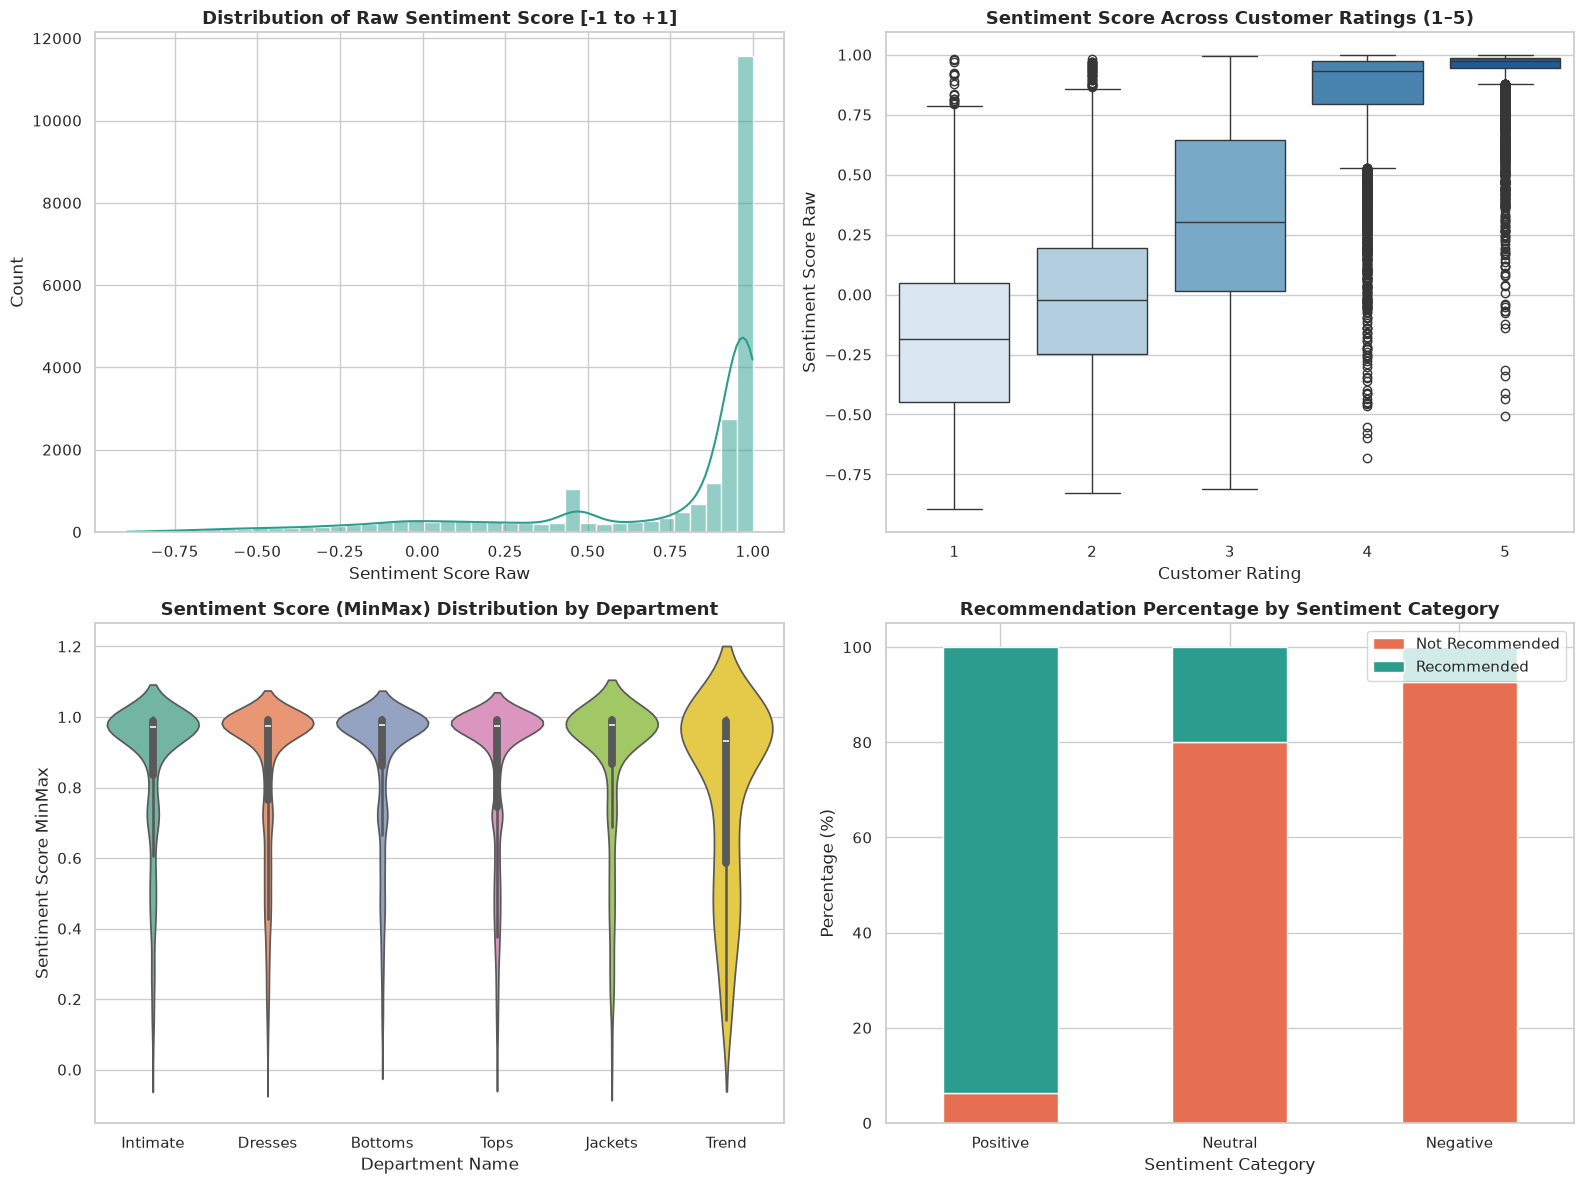

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df["Sentiment_Score_Raw"], bins=40, kde=True, color="#2A9D8F", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Raw Sentiment Score [-1 to +1]", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Sentiment Score Raw")

sns.boxplot(data=df, x="Rating", y="Sentiment_Score_Raw", palette="Blues", ax=axes[0, 1])
axes[0, 1].set_title("Sentiment Score Across Customer Ratings (1–5)", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Customer Rating")
axes[0, 1].set_ylabel("Sentiment Score Raw")

valid_depts = df[df["Department Name"].notna() & (df["Department Name"] != "Unknown")]
sns.violinplot(data=valid_depts, x="Department Name", y="Sentiment_Score_MinMax", palette="Set2", ax=axes[1, 0])
axes[1, 0].set_title("Sentiment Score (MinMax) Distribution by Department", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Department Name")
axes[1, 0].set_ylabel("Sentiment Score MinMax")

sentiment_rec_crosstab = pd.crosstab(df["Sentiment_Category"], df["Recommended IND"], normalize="index") * 100
sentiment_rec_crosstab = sentiment_rec_crosstab.reindex(["Positive", "Neutral", "Negative"])
sentiment_rec_crosstab.plot(kind="bar", stacked=True, color=["#E76F51", "#2A9D8F"], ax=axes[1, 1])
axes[1, 1].set_title("Recommendation Percentage by Sentiment Category", fontsize=13, fontweight="bold")
axes[1, 1].set_xlabel("Sentiment Category")
axes[1, 1].set_ylabel("Percentage (%)")
axes[1, 1].legend(["Not Recommended", "Recommended"], loc="upper right")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [13]:
output_columns = [
    "number", "Clothing ID", "Age", "Title", "Review Text", "Full_Review_Text",
    "Rating", "Recommended IND", "Positive Feedback Count",
    "Division Name", "Department Name", "Class Name",
    "Review_Word_Count", "Review_Char_Count",
    "Sentiment_Score_Raw", "Sentiment_Score_MinMax", "Sentiment_Score_Standardized",
    "Sentiment_Category", "Sentiment_Intensity", "Sentiment_Confidence"
]

final_export_dataframe = df[[col for col in output_columns if col in df.columns]]

final_export_dataframe.to_csv("womens_clothing_sentiment_features.csv", index=False)
model_comparison_table.to_csv("sentiment_model_comparison.csv", index=False)
department_sentiment_summary.to_csv("sentiment_department_summary.csv", index=False)
sentiment_correlation_matrix.to_csv("sentiment_rating_correlation.csv")

print("Files successfully exported:")
print("1. womens_clothing_sentiment_features.csv (Records: %d)" % len(final_export_dataframe))
print("2. sentiment_model_comparison.csv")
print("3. sentiment_department_summary.csv")
print("4. sentiment_rating_correlation.csv")

Files successfully exported:
1. womens_clothing_sentiment_features.csv (Records: 23486)
2. sentiment_model_comparison.csv
3. sentiment_department_summary.csv
4. sentiment_rating_correlation.csv
